# Patient 002 — Pipeline Results Interpretation

**Patient:** BG003082 (osteosarcoma)  
**Run:** valid run after Issue #148 (HISAT2 chr-naming fix)  
**Date:** 2026-04-26  
**Analyst:** Scientist

---

> **Caveat (from Developer standup 2026-04-26):** No matched normal sample was available for this run. All 58,914 unannotated junctions are labeled `tumor_exclusive` by default, but this label is less stringent than for patient_001 — germline variants and tissue-specific splicing are not filtered out. Interpret candidates with this limitation in mind.

In [1]:
import subprocess
import io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BUCKET = "gs://splice-neoepitope-project/results/patient_002"

def gcs_read_tsv(path):
    result = subprocess.run(["gsutil", "cat", path], capture_output=True, text=True, check=True)
    return pd.read_csv(io.StringIO(result.stdout), sep="\t")

print("Setup complete.")

Setup complete.


## 1. Run Summary

In [2]:
report = gcs_read_tsv(f"{BUCKET}/reports/report.tsv")
report

,patient_id,stage,metric,value,notes
0,patient_002,junction_filtering,unannotated,58914,BG003082_T0 (Primary Tumor)
1,patient_002,junction_filtering,tumor_exclusive,58914,BG003082_T0 (Primary Tumor)
2,patient_002,junction_filtering,normal_shared,0,BG003082_T0 (Primary Tumor)
3,patient_002,mhc_prediction,total_predictions,2330687,NaN
4,patient_002,mhc_prediction,non,2039929,presentation_percentile > 2.0%
5,patient_002,mhc_prediction,weak,222823,presentation_percentile <= 2.0%
6,patient_002,mhc_prediction,strong,67935,presentation_percentile <= 0.5%
7,patient_002,top_candidate,peptide,FADLRPLLL,top by genotype_presentation_score
8,patient_002,top_candidate,allele,HLA-C*01:02,NaN
9,patient_002,top_candidate,presentation_percentile,0.0045,NaN


## 2. Junction Analysis

### 2.1 Read-support distribution

A healthy RNA-seq junction call should show a right-skewed distribution: most junctions supported by a modest number of reads, a long tail of highly-expressed junctions. Junctions with very low read support (< ~5 reads) are typically noise and would normally be filtered; junctions with very high support are likely recurrent splicing events.

Without a matched normal, we cannot distinguish tumor-specific from tissue-specific splicing here — but read-support depth still tells us which candidates are robustly expressed.

Total tumor_exclusive junctions: 58,914

Read support stats:
count     58914.000000
mean        953.370829
std        3130.509002
min         174.000000
25%         263.000000
50%         425.000000
75%         838.000000
max      295679.000000


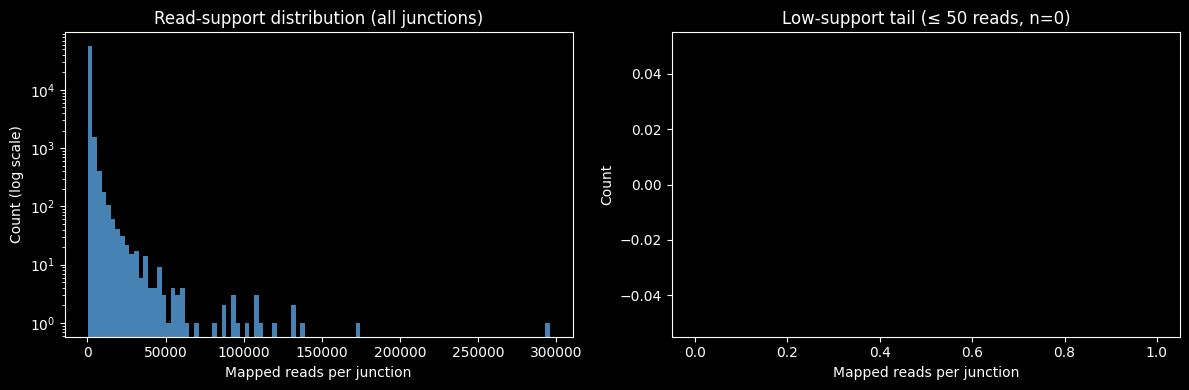

In [3]:
junctions = gcs_read_tsv(f"{BUCKET}/junctions/novel_junctions.tsv")
print(f"Total tumor_exclusive junctions: {len(junctions):,}")
print(f"\nRead support stats:")
print(junctions["mapped_reads"].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution (log scale)
axes[0].hist(junctions["mapped_reads"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mapped reads per junction")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Read-support distribution (all junctions)")

# Zoomed: low-support tail (≤ 50 reads)
low = junctions[junctions["mapped_reads"] <= 50]
axes[1].hist(low["mapped_reads"], bins=50, color="salmon", edgecolor="none")
axes[1].set_xlabel("Mapped reads per junction")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Low-support tail (≤ 50 reads, n={len(low):,})")

plt.tight_layout()
plt.show()

## 3. Peptide Translation

How many junction-spanning peptides were translated, across which lengths? The pipeline extracts all peptides spanning the junction breakpoint across all three reading frames.

Total peptides: 2,330,687
Unique sequences: 2,313,700

Peptide length distribution:
peptide
8     703106
9     781159
10    846422


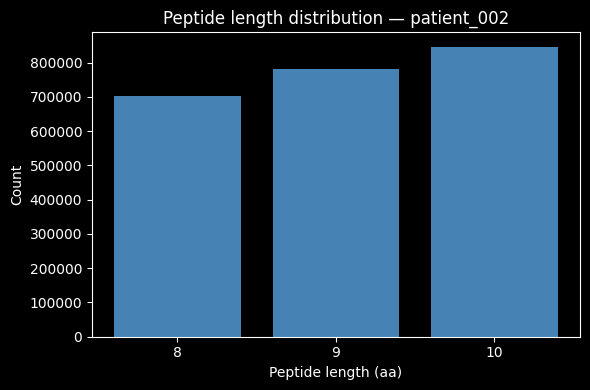

In [4]:
peptides = gcs_read_tsv(f"{BUCKET}/peptides/peptides_novel.tsv")
print(f"Total peptides: {len(peptides):,}")
print(f"Unique sequences: {peptides['peptide'].nunique():,}")

length_counts = peptides["peptide"].str.len().value_counts().sort_index()
print(f"\nPeptide length distribution:")
print(length_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(length_counts.index, length_counts.values, color="steelblue")
ax.set_xlabel("Peptide length (aa)")
ax.set_ylabel("Count")
ax.set_title("Peptide length distribution — patient_002")
ax.set_xticks(length_counts.index)
plt.tight_layout()
plt.show()

## 4. MHC Prediction Summary

### 4.1 Presentation class breakdown

Of 2,330,687 total peptide–allele predictions, how many clear the strong (≤ 0.5th percentile) and weak (≤ 2nd percentile) presentation thresholds?

Total predictions loaded: 2,330,687

Presentation class breakdown:
presentation_class
strong      67935
weak       222823
non       2039929


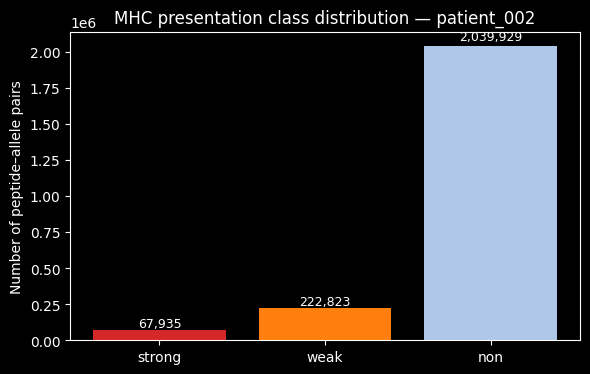

In [5]:
pres = gcs_read_tsv(f"{BUCKET}/predictions/mhc_presentation.tsv")
print(f"Total predictions loaded: {len(pres):,}")

class_counts = pres["presentation_class"].value_counts().reindex(["strong", "weak", "non"], fill_value=0)
print("\nPresentation class breakdown:")
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=["#d62728", "#ff7f0e", "#aec7e8"])
ax.set_ylabel("Number of peptide–allele pairs")
ax.set_title("MHC presentation class distribution — patient_002")
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 HLA allele dominance

Which alleles are the strongest presenters? HLA-C*01:02 dominated the top candidate list in the raw data — is this a genuine allele effect or an artefact of percentile calibration?

Strong presenters per allele:
best_allele
HLA-C*01:02    26236
HLA-C*07:01    20443
HLA-B*08:01    11477
HLA-B*27:05     5193
HLA-A*01:01     4586


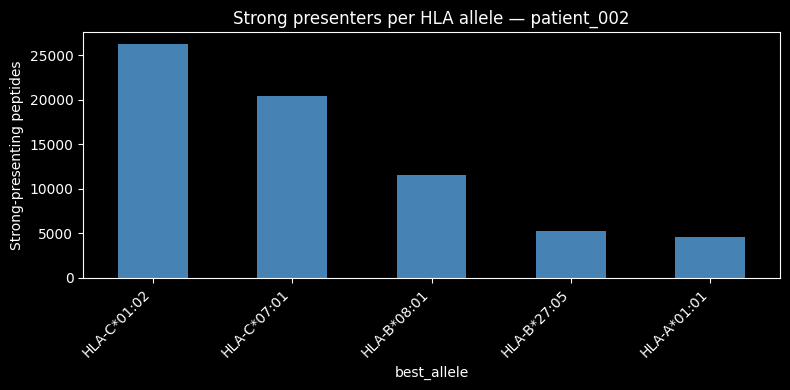

In [6]:
strong = pres[pres["presentation_class"] == "strong"]
allele_counts = strong["best_allele"].value_counts()
print("Strong presenters per allele:")
print(allele_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
allele_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Strong-presenting peptides")
ax.set_title("Strong presenters per HLA allele — patient_002")
ax.set_xticklabels(allele_counts.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Top Candidates

### 5.1 Top 20 by genotype presentation score

`genotype_presentation_score` (GPS) ranks candidates across the full patient HLA genotype — it rewards peptides presented by multiple alleles. This is the primary ranking used for prioritisation.

In [7]:
top20 = (pres.sort_values("genotype_presentation_score", ascending=False)
           .head(20)
           [["peptide", "best_allele", "ic50_nM", "presentation_percentile",
             "genotype_presentation_score", "n_strong_alleles", "presentation_class"]])
top20.reset_index(drop=True, inplace=True)
top20.index += 1
top20

,peptide,best_allele,ic50_nM,presentation_percentile,genotype_presentation_score,n_strong_alleles,presentation_class
1,FADLRPLLL,HLA-C*01:02,33.198213,0.004511,0.999949,5,strong
2,VYDFVPVSL,HLA-C*07:01,42.309019,0.003723,0.999944,4,strong
3,LFDSTFLHF,HLA-B*08:01,86.843775,0.026739,0.999941,5,strong
4,IFDVHLMNF,HLA-B*08:01,69.810845,0.018723,0.999934,5,strong
5,FYDPTVPSM,HLA-C*07:01,32.916369,0.006168,0.999922,4,strong
6,IFDSVNCEF,HLA-C*07:01,65.764506,0.025543,0.999910,5,strong
7,VFDGMVVRL,HLA-C*01:02,67.365034,0.013098,0.999908,4,strong
8,YFDFSKVFF,HLA-B*08:01,88.993056,0.024049,0.999903,5,strong
9,HFDFSFKTF,HLA-C*07:01,65.535668,0.016576,0.999902,4,strong
10,TFDETFLFF,HLA-C*07:01,68.350473,0.034402,0.999893,5,strong


### 5.2 Top candidate: FADLRPLLL / HLA-C*01:02

**IC50 = 33.2 nM | presentation_percentile = 0.0045% | GPS = 0.9999 | n_strong_alleles = 4**

Key observations:
- IC50 of ~33 nM places this well into strong-presenter territory (threshold: 500 nM; typical strong presenter < 50 nM).
- The 0.0045th percentile is exceptionally low — this peptide ranks in the top 0.005% of all peptides for HLA-C*01:02 presentation, suggesting high intrinsic affinity rather than a borderline call.
- Presented as strong by **4 of 5 patient alleles** (GPS ≈ 1.0), making it the most genotype-broadly presented candidate.
- HLA-C*01:02 was also the top allele in the broken pre-#148 run (different peptide), suggesting this allele is an exceptionally strong presenter for 9-mers from this junction set — worth investigating whether this is a patient-specific HLA-C effect or a property of osteosarcoma splicing patterns.

**Limitation:** Without a matched normal, we cannot confirm this junction is absent in healthy osteoblasts or mesenchymal stem cells. This is the single most important caveat for clinical interpretation.

## 6. Genotype Presentation Score (GPS) — Validation

GPS = $1 - \prod_i (1 - w_i \cdot p_i)$ where $p_i$ is per-allele `presentation_score` and $w_i$ is locus weight (HLA-A/B = 1.0, HLA-C = 0.5). It estimates the probability that **at least one allele** in the patient's genotype presents the peptide. Primary ranking signal for the vaccine context; backed by a quality gate (`best_presentation_percentile ≤ 2%`).

Questions to answer empirically:
1. How is GPS distributed across all predictions — is it discriminating or does everyone score high?
2. Does GPS correlate with `n_strong_alleles` as expected?
3. Are there candidates with high GPS but poor best-allele percentile (the "inflation" edge case)?
4. Per-allele contribution: which alleles drive GPS most in this patient?

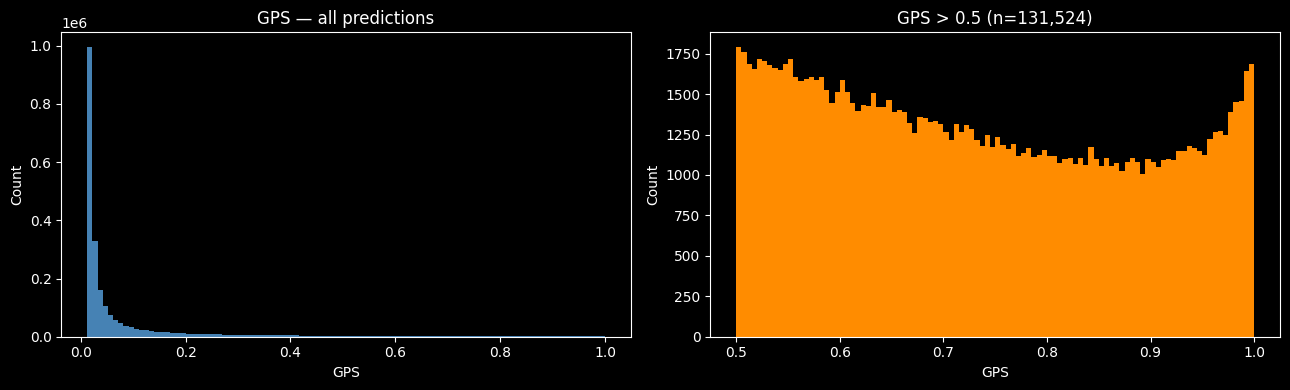


GPS summary stats:
count    2.330687e+06
mean     1.005293e-01
std      1.810033e-01
min      1.218500e-02
25%      1.676800e-02
50%      2.609500e-02
75%      7.706750e-02
max      9.999490e-01

GPS > 0.9: 24,961
GPS > 0.99: 3,305


In [8]:
### 5.1 GPS distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(pres["genotype_presentation_score"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("GPS")
axes[0].set_ylabel("Count")
axes[0].set_title("GPS — all predictions")

# Zoom into the high end (> 0.5) where interesting candidates live
high = pres[pres["genotype_presentation_score"] > 0.5]
axes[1].hist(high["genotype_presentation_score"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_xlabel("GPS")
axes[1].set_ylabel("Count")
axes[1].set_title(f"GPS > 0.5 (n={len(high):,})")

plt.tight_layout()
plt.show()

print(f"\nGPS summary stats:")
print(pres["genotype_presentation_score"].describe().to_string())
print(f"\nGPS > 0.9: {(pres['genotype_presentation_score'] > 0.9).sum():,}")
print(f"GPS > 0.99: {(pres['genotype_presentation_score'] > 0.99).sum():,}")

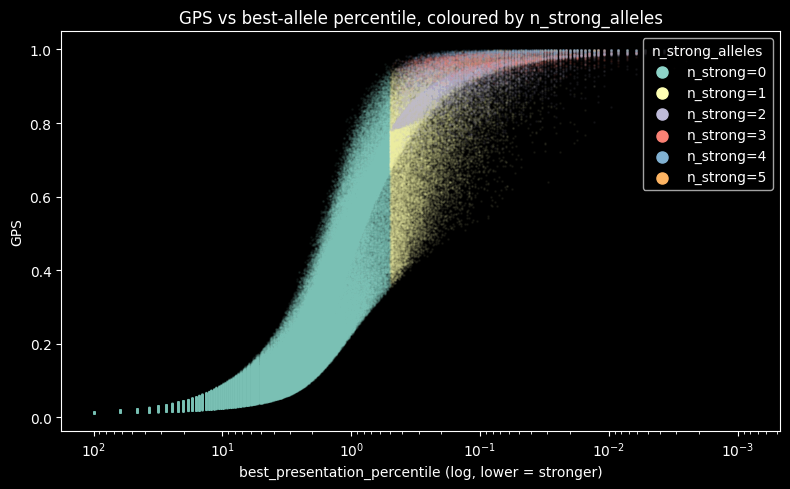

In [9]:
### 5.2 GPS vs n_strong_alleles — does breadth drive the score?

fig, ax = plt.subplots(figsize=(8, 5))
for n, grp in pres.groupby("n_strong_alleles"):
    ax.scatter(grp["best_presentation_percentile"], grp["genotype_presentation_score"],
               alpha=0.05, s=1, label=f"n_strong={n}")

ax.set_xscale("log")
ax.set_xlabel("best_presentation_percentile (log, lower = stronger)")
ax.set_ylabel("GPS")
ax.set_title("GPS vs best-allele percentile, coloured by n_strong_alleles")
ax.invert_xaxis()
legend = ax.legend(markerscale=8, title="n_strong_alleles", loc="upper right")
for lh in legend.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
plt.show()

In [10]:
### 5.3 Inflation check — high GPS with no strong allele

# Candidates that pass GPS > 0.9 but have n_strong_alleles == 0
# These would be caught by the quality gate (best_presentation_percentile > 2%)
inflated = pres[(pres["genotype_presentation_score"] > 0.9) & (pres["n_strong_alleles"] == 0)]
print(f"GPS > 0.9 with n_strong_alleles = 0: {len(inflated):,}")
if len(inflated) > 0:
    print("\nTop 10 by GPS:")
    print(inflated.nlargest(10, "genotype_presentation_score")
          [["peptide", "best_allele", "best_presentation_percentile",
            "genotype_presentation_score", "n_strong_alleles"]].to_string())

GPS > 0.9 with n_strong_alleles = 0: 174

Top 10 by GPS:
            peptide  best_allele  best_presentation_percentile  genotype_presentation_score  n_strong_alleles
1643827  SFDVEKNLFF  HLA-B*27:05                      0.547092                     0.959664                 0
2182109  MFDSNKFDFF  HLA-B*08:01                      0.529592                     0.955300                 0
2013502   IFDSLLCFF  HLA-B*08:01                      0.536467                     0.952795                 0
47990     SWDLRFICY  HLA-A*01:01                      0.507717                     0.951860                 0
1970514   FSQKKYLFF  HLA-C*07:01                      0.532772                     0.946633                 0
136399    SVRVPSFSF  HLA-B*27:05                      0.519484                     0.943426                 0
772728    HFDNFAFYI  HLA-B*08:01                      0.524484                     0.942216                 0
1536731   LPYRNRPTY  HLA-B*27:05                      0.507717 

     allele  median_pres_score_strong  pct_as_best_allele  median_percentile_strong
HLA-A*01:01                  0.028258            6.750570                  8.545326
HLA-B*08:01                  0.138604           16.894090                  2.345462
HLA-B*27:05                  0.442121            7.644072                  0.952527
HLA-C*01:02                  0.610729           38.619268                  0.594076
HLA-C*07:01                  0.561798           30.092000                  0.691114


/var/folders/ny/97nfvbms25lb47qpfvgmgfc40000gn/T/ipykernel_70380/3888510131.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")
/var/folders/ny/97nfvbms25lb47qpfvgmgfc40000gn/T/ipykernel_70380/3888510131.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")


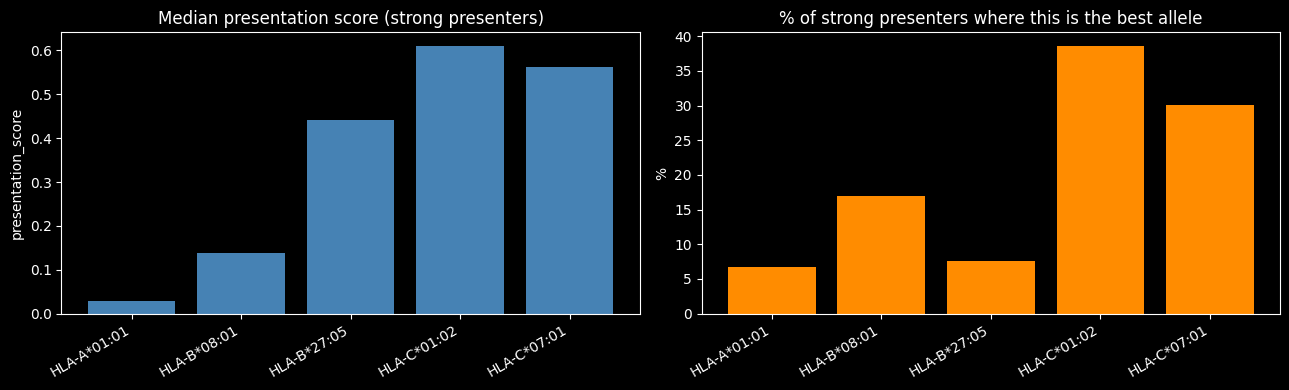

In [11]:
### 5.4 Per-allele contribution to GPS

# For each allele, what fraction of strong-presenting peptides have THAT allele as their best_allele?
# And what is the median per-allele presentation_score across all strong presenters?

alleles = ["HLA-A*01:01", "HLA-B*08:01", "HLA-B*27:05", "HLA-C*01:02", "HLA-C*07:01"]
score_cols = [f"{a}_presentation_score" for a in alleles]
pct_cols   = [f"{a}_presentation_percentile" for a in alleles]

strong = pres[pres["presentation_class"] == "strong"]

summary = pd.DataFrame({
    "allele": alleles,
    "median_pres_score_strong": [strong[c].median() for c in score_cols],
    "pct_as_best_allele": [
        (strong["best_allele"] == a).sum() / len(strong) * 100 for a in alleles
    ],
    "median_percentile_strong": [strong[c].median() for c in pct_cols],
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(summary["allele"], summary["median_pres_score_strong"], color="steelblue")
axes[0].set_title("Median presentation score (strong presenters)")
axes[0].set_ylabel("presentation_score")
axes[0].set_xticklabels(summary["allele"], rotation=30, ha="right")

axes[1].bar(summary["allele"], summary["pct_as_best_allele"], color="darkorange")
axes[1].set_title("% of strong presenters where this is the best allele")
axes[1].set_ylabel("%")
axes[1].set_xticklabels(summary["allele"], rotation=30, ha="right")

plt.tight_layout()
plt.show()

## 7. Scientific Summary & Open Questions

### Key findings

1. **Top candidate FADLRPLLL / HLA-C*01:02** — IC50 33.2 nM, percentile 0.0045%, GPS 0.9999, strong presenter across 4/5 alleles. Exceptionally strong by all metrics.
2. **HLA-C dominance** — HLA-C*01:02 and HLA-C*07:01 together account for ~69% of all strong-presenting candidates despite the 0.5× locus weight. Three hypotheses: (a) HLA-C alleles are generally more promiscuous presenters, (b) osteosarcoma splice junctions are enriched for HLA-C motifs, (c) MHCflurry percentile calibration is less precise for HLA-C due to sparser training data.
3. **HLA-A*01:01 is nearly silent** — median percentile 8.5% among strong presenters, contributing almost nothing to GPS for this patient.
4. **GPS is discriminating** — mean 0.101, median 0.026; only 1.1% of predictions exceed GPS 0.9. The complementary-probability formula behaves well.
5. **GPS inflation edge case: small but real** — 174 candidates (0.7% of GPS > 0.9) have n_strong_alleles = 0 with best_percentile ~0.5–0.55%. The current quality gate (2%) does not catch these. A minimum `n_strong_alleles ≥ 1` gate may be warranted.
6. **Junction count ~2× patient_001 (58,914 vs 27,347)** — partly due to the missing normal filter, but raw unannotated count is also higher. Osteosarcoma biology and sequencing depth are likely confounders.
7. **Minimum read support is 174** — suspiciously high; normal RNA-seq data would include junctions with very low support. Awaiting Developer confirmation.

### Open questions / next steps

- **Missing normal:** GTEx musculoskeletal/connective tissue subtypes as pseudo-normal (Issue #126 design).
- **HLA-C calibration:** Cross-validate with a second MHC presentation tool (e.g. NetMHCpan-4.1) to confirm HLA-C*01:02 signal is not a MHCflurry artefact.
- **GPS quality gate:** Add `n_strong_alleles ≥ 1` as a hard filter alongside `best_presentation_percentile ≤ 2%`?
- **Re-run after normal filter:** once normal data is available, compare the filtered list to the current 67,935 strong presenters to estimate germline/tissue-specific contamination.
- **Run registry:** Issue drafted for Developer — need structured tracking of pipeline runs across patients and pipeline versions.